# Train Model Workflow

This notebook mirrors `train_model.py`, organized into logical steps.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMClassifier, LGBMRegressor
import lightgbm as lgb
import joblib

## 2. Load And Prepare Dataset

In [2]:
# Load dataset
df = pd.read_csv('dataset.csv')
df = df.sort_values(by='game_date')  # Sort by date

In [3]:
df.drop(columns=['fast_break_pct_avg_diff','fast_break_pct_rolling_5_diff','points_off_turnover_pct_avg_diff','points_off_turnover_pct_rolling_5_diff'], inplace=True)

In [4]:
print("Number of nulls per column in df (ordered by highest nulls first):")
null_counts = df.isnull().sum().sort_values(ascending=False)
for col, count in null_counts.items():
    print(f"{col}: {count}")

Number of nulls per column in df (ordered by highest nulls first):
game_id: 0
season: 0
season_type: 0
game_date: 0
team_home_away: 0
team_winner: 0
is_early_season: 0
spread: 0
sos: 0
sos_opp: 0
threes_advantage: 0
threes_disadvantage: 0
two_pointers_advantage: 0
two_pointers_disadvantage: 0
free_throws_advantage: 0
free_throws_disadvantage: 0
adj_sos: 0
adj_sos_opp: 0
off_vs_def: 0
def_vs_off: 0
tov_vs_stl: 0
stl_vs_tov: 0
orb_vs_drb: 0
drb_vs_orb: 0
pace_diff: 0
exp_poss: 0
efg_vs_efg_allowed: 0
efg_allowed_vs_efg: 0
margin_estimate: 0
home_off_away_def: 0
home_def_away_off: 0
away_off_home_def: 0
away_def_home_off: 0
quad_score: 0
three_variance_diff: 0
score_variance_diff: 0
def_score_variance_diff: 0
off_eff_variance_diff: 0
pace_variance_diff: 0
elo_diff: 0
last_10_efficiency_diff: 0
team_score_avg_diff: 0
team_score_rolling_5_diff: 0
opponent_team_score_avg_diff: 0
opponent_team_score_rolling_5_diff: 0
poss_avg_diff: 0
poss_rolling_5_diff: 0
poss_opponent_avg_diff: 0
poss_oppon

## 3. Train/Test Split And Shared Config

In [6]:
# Split train/test based on date
split_date = '2024-11-01'
df['target'] = df['team_winner']
df.drop(columns=['team_winner'], inplace=True)
train_df = df[df['game_date'] <= split_date].copy()
test_df = df[df['game_date'] > split_date].copy()
train_df.drop(columns=['game_date','game_id'], inplace=True)
test_df.drop(columns=['game_date','game_id'], inplace=True)

In [7]:
train_df.tail(10)

,season,season_type,team_home_away,is_early_season,spread,sos,sos_opp,threes_advantage,threes_disadvantage,two_pointers_advantage,...,win_loss_pct_diff,non_conf_win_loss_pct_diff,conference_nonconf_win_pct_diff,luck_diff,rank_diff,adj_off_eff_diff,adj_def_eff_diff,adj_net_eff_diff,power_rating_diff,target
202830,2024,3,2,1,10,3.688678,8.262027,0.069200,-0.030872,0.007878,...,0.217460,-0.043288,-0.089838,0.103236,-40.0,15.030773,11.664135,3.366638,-4.562673,1
202831,2024,3,2,1,-10,8.262027,3.688678,0.030872,-0.069200,-0.000601,...,-0.217460,0.043288,0.089838,-0.103236,40.0,-15.031015,-11.664098,-3.366917,4.563314,0
202834,2024,3,2,1,-2,3.910283,8.100874,0.050796,0.014110,0.028820,...,0.166667,-0.016115,-0.026650,-0.008525,-78.0,6.731685,5.407877,1.323808,-0.573397,0
202835,2024,3,2,1,2,8.100874,3.910283,-0.014110,-0.050796,0.031059,...,-0.166667,0.016115,0.026650,0.008525,78.0,-6.731749,-5.407964,-1.323785,0.574775,1
202836,2024,3,2,1,-13,7.451850,8.056203,-0.003472,-0.017347,0.035868,...,-0.250866,-0.031451,-0.031961,0.006979,151.0,-7.485801,-5.927208,-1.558593,-33.284071,0
202837,2024,3,2,1,13,8.056203,7.451850,0.017347,0.003472,0.036417,...,0.250866,0.031451,0.031961,-0.006979,-151.0,7.485842,5.927198,1.558644,33.282581,1
202838,2024,3,2,1,-14,13.177322,5.806761,0.072161,-0.025453,0.017594,...,-0.226608,0.041670,0.050914,-0.060467,17.0,19.666175,13.733721,5.932454,1.191670,0
202839,2024,3,2,1,14,5.806761,13.177322,0.025453,-0.072161,0.034772,...,0.226608,-0.041670,-0.050914,0.060467,-17.0,-19.665741,-13.733707,-5.932034,-1.200935,1
202840,2024,3,2,1,-15,7.896952,6.117722,0.037934,-0.028621,0.061285,...,-0.028340,-0.002698,0.019550,0.023860,2.0,2.021446,1.297132,0.724314,3.622524,0
202841,2024,3,2,1,15,6.117722,7.896952,0.028621,-0.037934,0.052771,...,0.028340,0.002698,-0.019550,-0.023860,-2.0,-2.021450,-1.297152,-0.724298,-3.631419,1


## 4. Train Winner Prediction Model

In [ ]:
# Winner prediction model (classification)

# Drop the other target column to avoid leakage
X_train_winner = train_df.drop(columns=['target','spread'])
y_train_winner = train_df['target'].astype(int)

X_test_winner = test_df.drop(columns=['target','spread'])
y_test_winner = test_df['target'].astype(int)

print(X_train_winner.columns.to_list())

# Improved model parameters for better generalization and handling nonlinearity
winner_params = dict(
    objective="binary",
    boosting_type="gbdt",
    learning_rate=0.04,           # Slower learning rate for more robust learning
    n_estimators=2000,             # More trees to compensate for lower learning rate
    max_depth=7,                   # Slightly deeper trees to fit more complex patterns
    num_leaves=96,                # More leaves to capture nonlinearity
    min_child_samples=50,          # Reduce overfitting, but not too high to retain learning small data regions
    feature_fraction=0.85,         # Try more features per tree
    bagging_fraction=0.85,         # Slightly more bagging for generalization
    bagging_freq=1,
    lambda_l1=1.0,                 # Slightly stronger L1 to encourage sparsity
    lambda_l2=6.0,                 # Slightly stronger L2 for regularization
    min_gain_to_split=0.005,       # Require a bit more information gain to split
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    metric="auc",
    early_stopping_rounds=200
)

model_winner = LGBMClassifier(**winner_params)

print("\nTraining winner prediction model (improved hyperparameters)...")
model_winner.fit(
    X_train_winner,
    y_train_winner,
    eval_set=[(X_train_winner, y_train_winner), (X_test_winner, y_test_winner)],
    eval_names=['Train', 'Test'],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=200, first_metric_only=True)]
)

['season', 'season_type', 'team_home_away', 'is_early_season', 'sos', 'sos_opp', 'threes_advantage', 'threes_disadvantage', 'two_pointers_advantage', 'two_pointers_disadvantage', 'free_throws_advantage', 'free_throws_disadvantage', 'adj_sos', 'adj_sos_opp', 'off_vs_def', 'def_vs_off', 'tov_vs_stl', 'stl_vs_tov', 'orb_vs_drb', 'drb_vs_orb', 'pace_diff', 'exp_poss', 'efg_vs_efg_allowed', 'efg_allowed_vs_efg', 'margin_estimate', 'home_off_away_def', 'home_def_away_off', 'away_off_home_def', 'away_def_home_off', 'quad_score', 'three_variance_diff', 'score_variance_diff', 'def_score_variance_diff', 'off_eff_variance_diff', 'pace_variance_diff', 'elo_diff', 'last_10_efficiency_diff', 'team_score_avg_diff', 'team_score_rolling_5_diff', 'opponent_team_score_avg_diff', 'opponent_team_score_rolling_5_diff', 'poss_avg_diff', 'poss_rolling_5_diff', 'poss_opponent_avg_diff', 'poss_opponent_rolling_5_diff', 'off_eff_avg_diff', 'off_eff_rolling_5_diff', 'def_eff_avg_diff', 'def_eff_rolling_5_diff', '

,boosting_type,'gbdt'
,num_leaves,96
,max_depth,7
,learning_rate,0.04
,n_estimators,2000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


## 5. Save Models

In [108]:
joblib.dump(model_winner, 'models/lgbm_winner_model.joblib')

['models/lgbm_winner_model.joblib']

## 6. Define Evaluation Helper

In [19]:


def evaluate_classification_thresholds(model, X_test, y_test, model_name):
    from sklearn.metrics import matthews_corrcoef

    thresholds = np.linspace(0.1, 0.8, 10)  # Test thresholds from 0.1 to 0.8
    metrics = []

    # Get probabilities once
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    for thresh in thresholds:
        # Get predictions based on threshold
        y_pred_thresh = (y_pred_proba > thresh).astype(int)

        # Calculate standard metrics
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)
        accuracy = accuracy_score(y_test, y_pred_thresh)
        mcc = matthews_corrcoef(y_test, y_pred_thresh)

        metrics.append([thresh, precision, recall, f1, accuracy, mcc])

    # Convert to DataFrame
    metrics_df = pd.DataFrame(
        metrics,
        columns=[
            "Threshold", "Precision", "Recall", "F1 Score", "Accuracy", "Matthews_CC",
        ]
    )

    # Plot metrics
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=metrics_df, x="Threshold", y="Precision", label="Precision", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Recall", label="Recall", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="F1 Score", label="F1 Score", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy", label="Accuracy", marker="o")
    sns.lineplot(
        data=metrics_df,
        x="Threshold",
        y="Matthews_CC",
        label="Matthews Corr. Coefficient",
        marker="o",
        linestyle="--",
        color="darkgreen"
    )

    

    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Optimization - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    # Find and return the best threshold based on Matthews Correlation Coefficient (MCC)
    best_threshold = metrics_df.loc[metrics_df["Matthews_CC"].idxmax(), "Threshold"]

    return best_threshold


## 7. Evaluate Models

[LightGBM] [Warning] feature_fraction is set=0.85, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.85
[LightGBM] [Warning] min_gain_to_split is set=0.005, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.005
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=6.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=6.0
[LightGBM] [Warning] bagging_fraction is set=0.85, subsample=1.0 will be ignored. Current value: bagging_fraction=0.85
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1


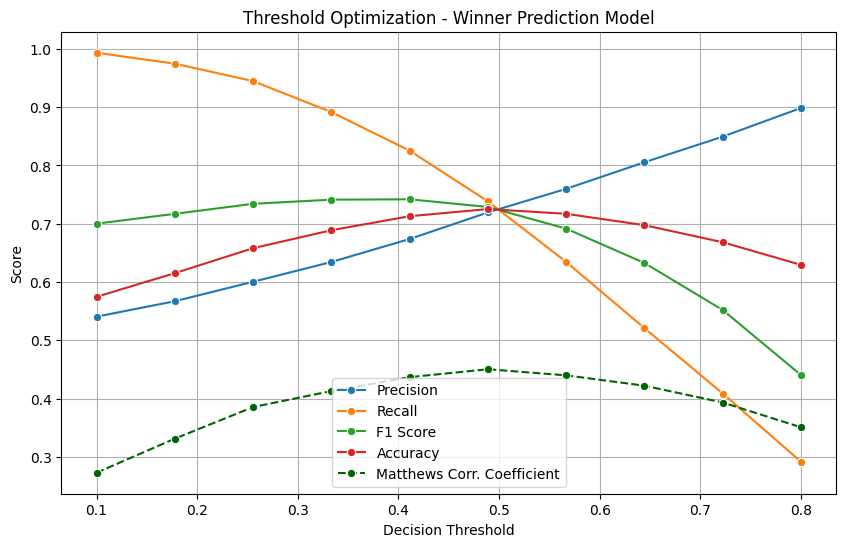

ROC AUC: 0.8058

Optimal Decision Threshold (Winner Model): 0.49


In [20]:
best_thresh_winner = evaluate_classification_thresholds(model_winner, X_test_winner, y_test_winner, "Winner Prediction Model")

print(f"\nOptimal Decision Threshold (Winner Model): {best_thresh_winner:.2f}")

## 8. Define Feature Importance Helper

In [21]:
def plot_feature_importance(model, X_train, model_name):
    feature_importances = model.feature_importances_
    feature_names = X_train.columns

    feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    top_20_features = feat_importance_df.sort_values(by="Importance", ascending=False).head(30)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title(f"Top 20 Features - {model_name}")
    plt.show()

## 9. Plot Feature Importances

C:\Users\johns\AppData\Local\Temp\ipykernel_6172\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


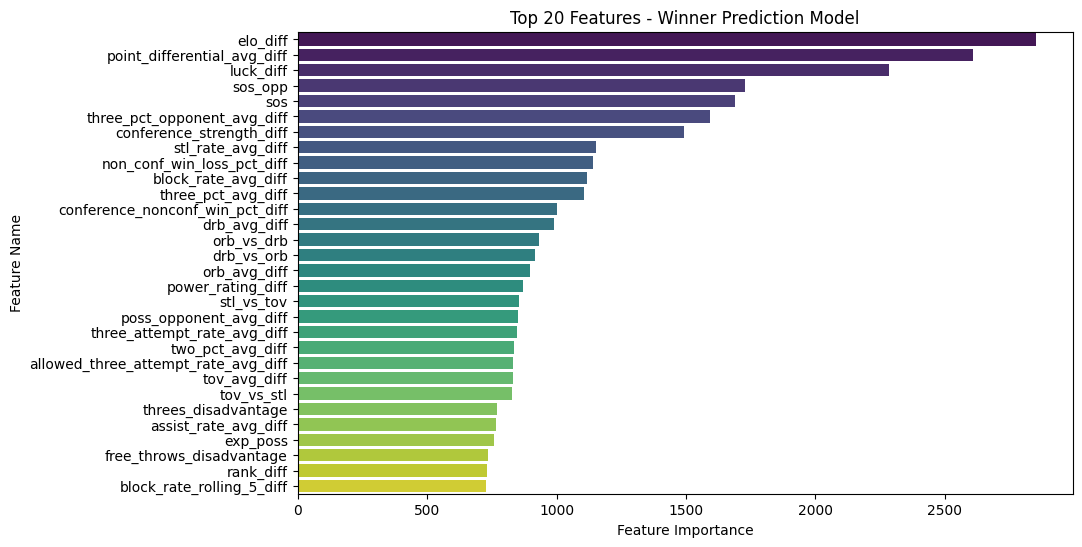

In [14]:
plot_feature_importance(model_winner, X_train_winner, "Winner Prediction Model")

In [ ]:
# Winner prediction model (classification)

# Drop the other target column to avoid leakage
X_train_spread = train_df.drop(columns=['target','spread'])
y_train_spread = train_df['spread'].astype(int)

X_test_spread = test_df.drop(columns=['target','spread'])
y_test_spread = test_df['spread'].astype(int)

print(X_train_spread.columns.to_list())

# Improved model parameters for better generalization and handling nonlinearity (regression)
spread_params = dict(
    objective="regression",
    metric="rmse",
    boosting_type="gbdt",
    learning_rate=0.04,           # Slower learning rate for more robust learning
    n_estimators=2000,             # More trees to compensate for lower learning rate
    max_depth=7,                   # Slightly deeper trees to fit more complex patterns
    num_leaves=96,                # More leaves to capture nonlinearity
    min_child_samples=50,          # Reduce overfitting, but not too high to retain learning small data regions
    feature_fraction=0.85,         # Try more features per tree
    bagging_fraction=0.85,         # Slightly more bagging for generalization
    bagging_freq=1,
    lambda_l1=1.0,                 # Slightly stronger L1 to encourage sparsity
    lambda_l2=6.0,                 # Slightly stronger L2 for regularization
    min_gain_to_split=0.005,       # Require a bit more information gain to split
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    early_stopping_rounds=200
    # Remove early_stopping_rounds, eval_set, eval_names, eval_metric, callbacks from constructor
)

model_spread = LGBMRegressor(**spread_params)

print("\nTraining winner prediction model (improved hyperparameters)...")
model_spread.fit(
    X_train_spread, y_train_spread,
    eval_set=[(X_train_spread, y_train_spread), (X_test_spread, y_test_spread)],
    eval_names=['Train', 'Test'],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=200, first_metric_only=True)]
)

['season', 'season_type', 'team_home_away', 'is_early_season', 'sos', 'sos_opp', 'threes_advantage', 'threes_disadvantage', 'two_pointers_advantage', 'two_pointers_disadvantage', 'free_throws_advantage', 'free_throws_disadvantage', 'adj_sos', 'adj_sos_opp', 'off_vs_def', 'def_vs_off', 'tov_vs_stl', 'stl_vs_tov', 'orb_vs_drb', 'drb_vs_orb', 'pace_diff', 'exp_poss', 'efg_vs_efg_allowed', 'efg_allowed_vs_efg', 'margin_estimate', 'home_off_away_def', 'home_def_away_off', 'away_off_home_def', 'away_def_home_off', 'quad_score', 'three_variance_diff', 'score_variance_diff', 'def_score_variance_diff', 'off_eff_variance_diff', 'pace_variance_diff', 'elo_diff', 'last_10_efficiency_diff', 'team_score_avg_diff', 'team_score_rolling_5_diff', 'opponent_team_score_avg_diff', 'opponent_team_score_rolling_5_diff', 'poss_avg_diff', 'poss_rolling_5_diff', 'poss_opponent_avg_diff', 'poss_opponent_rolling_5_diff', 'off_eff_avg_diff', 'off_eff_rolling_5_diff', 'def_eff_avg_diff', 'def_eff_rolling_5_diff', '

,boosting_type,'gbdt'
,num_leaves,96
,max_depth,7
,learning_rate,0.04
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [23]:

def evaluate_regression_thresholds(model, X_test, y_test, model_name):
    """
    Evaluate thresholds for the regression task, mapping predicted spread > threshold to win (1), else loss (0).
    Additionally, always compute the hard classification: pred > 0 => winner.
    Prints ROC AUC for regression probabilities.
    """
    from sklearn.metrics import matthews_corrcoef, roc_auc_score

    thresholds = np.linspace(-10, 10, 21)  # Try thresholds from -10 to 10
    metrics = []

    # Get regression predictions (spread)
    y_pred_raw = model.predict(X_test)

    # Compute ROC AUC for regression output as probabilities (using spread as score for winner class = 1)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_raw)
        print(f"ROC AUC (raw regression scores): {roc_auc:.4f}")
    except Exception as e:
        print(f"ROC AUC computation failed: {str(e)}")

    for thresh in thresholds:
        # Mask spread prediction: classify as win (1) if pred > thresh, else loss (0)
        y_pred_thresh = (y_pred_raw > thresh).astype(int)

        # Calculate metrics for this threshold
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)
        accuracy = accuracy_score(y_test, y_pred_thresh)
        mcc = matthews_corrcoef(y_test, y_pred_thresh)

        metrics.append([thresh, precision, recall, f1, accuracy, mcc])

    # Also evaluate the standard "pred > 0" as a classification prediction
    y_pred_binary = (y_pred_raw > 0).astype(int)
    binary_metrics = {
        "Precision": precision_score(y_test, y_pred_binary),
        "Recall": recall_score(y_test, y_pred_binary),
        "F1 Score": f1_score(y_test, y_pred_binary),
        "Accuracy": accuracy_score(y_test, y_pred_binary),
        "Matthews_CC": matthews_corrcoef(y_test, y_pred_binary)
    }
    print("\nMetrics for hard mask (prediction > 0 ==> Winner):")
    print(f"Precision: {binary_metrics['Precision']:.4f}")
    print(f"Recall:    {binary_metrics['Recall']:.4f}")
    print(f"F1 Score:  {binary_metrics['F1 Score']:.4f}")
    print(f"Accuracy:  {binary_metrics['Accuracy']:.4f}")
    print(f"MCC:       {binary_metrics['Matthews_CC']:.4f}\n")

    # Convert to DataFrame
    metrics_df = pd.DataFrame(
        metrics,
        columns=[
            "Threshold", "Precision", "Recall", "F1 Score", "Accuracy", "Matthews_CC",
        ]
    )

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=metrics_df, x="Threshold", y="Precision", label="Precision", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Recall", label="Recall", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="F1 Score", label="F1 Score", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy", label="Accuracy", marker="o")
    sns.lineplot(
        data=metrics_df,
        x="Threshold",
        y="Matthews_CC",
        label="Matthews Corr. Coefficient",
        marker="o",
        linestyle="--",
        color="darkgreen"
    )

    plt.xlabel("Spread Threshold (win if pred > thresh)")
    plt.ylabel("Score")
    plt.title(f"Threshold Optimization for Regression-as-Classification - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Best metrics over thresholds (MCC):")
    print(metrics_df.loc[metrics_df['Matthews_CC'].idxmax()])

    # Find and return the best threshold based on Matthews Correlation Coefficient (MCC)
    best_threshold = metrics_df.loc[metrics_df["Matthews_CC"].idxmax(), "Threshold"]

    return best_threshold


[LightGBM] [Warning] feature_fraction is set=0.85, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.85
[LightGBM] [Warning] min_gain_to_split is set=0.005, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.005
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=6.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=6.0
[LightGBM] [Warning] bagging_fraction is set=0.85, subsample=1.0 will be ignored. Current value: bagging_fraction=0.85
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
ROC AUC (raw regression scores): 0.8062

Metrics for hard mask (prediction > 0 ==> Winner):
Precision: 0.7240
Recall:    0.7249
F1 Score:  0.7244
Accuracy:  0.7242
MCC:       0.4485



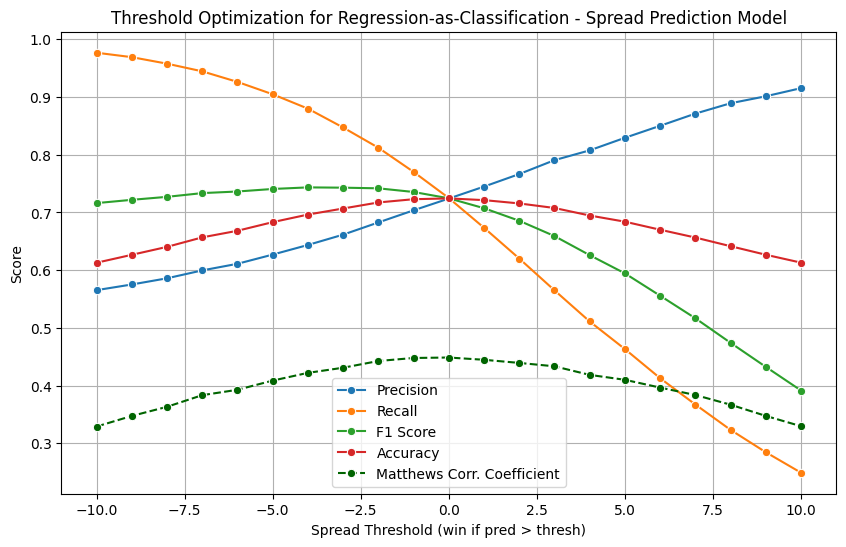

Best metrics over thresholds (MCC):
Threshold      0.000000
Precision      0.723961
Recall         0.724876
F1 Score       0.724418
Accuracy       0.724244
Matthews_CC    0.448488
Name: 10, dtype: float64

Optimal Decision Threshold (Spread Model): 0.00


In [24]:
best_thresh_spread = evaluate_regression_thresholds(model_spread, X_test_spread, y_test_winner, "Spread Prediction Model")

print(f"\nOptimal Decision Threshold (Spread Model): {best_thresh_spread:.2f}")

C:\Users\johns\AppData\Local\Temp\ipykernel_6172\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


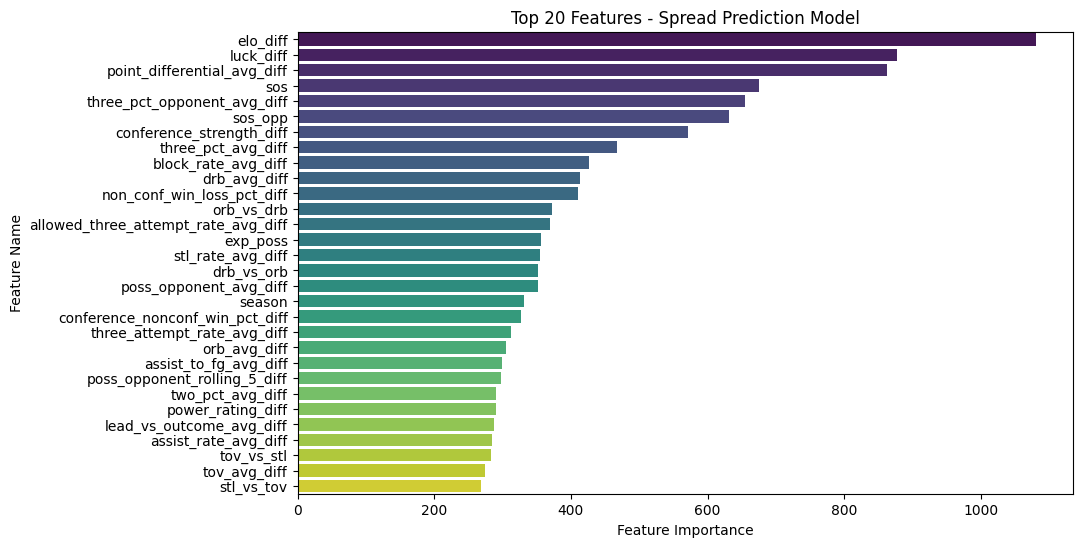

In [25]:
plot_feature_importance(model_spread, X_train_spread, "Spread Prediction Model")

In [66]:
joblib.dump(model_spread, 'models/lgbm_spread_model.joblib')

['models/lgbm_spread_model.joblib']